# Model : Simple Linear Regression

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt

# Importing the dataset

In [2]:
df = pd.read_csv('Salary_Data.csv')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

## Splitting dataset into Training and Test 

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
x_train , x_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state= 0)

## Training the Simple Linear Regression on the Training set

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
regressor = LinearRegression()
regressor.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predict the Test Set results:

In [7]:
y_pred = regressor.predict(x_test)

In [8]:
y_pred

array([ 40748.96184072, 122699.62295594,  64961.65717022,  63099.14214487,
       115249.56285456, 107799.50275317])

## Visualising  the training set results

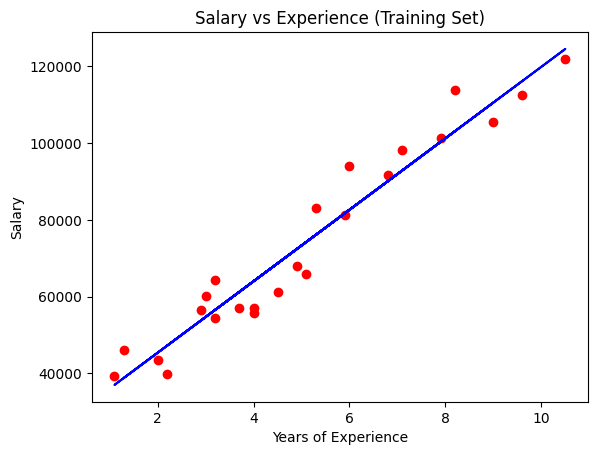

In [9]:
plt.scatter(x_train , y_train , color = 'red')
plt.plot(x_train , regressor.predict(x_train) , color = 'blue')
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

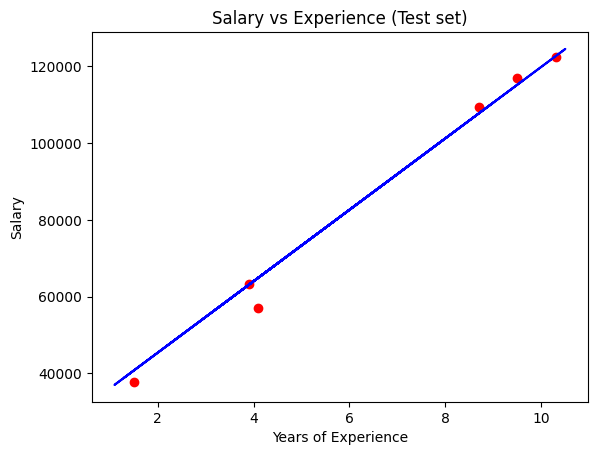

In [10]:
# Visualising the Test set results

plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train, regressor.predict(x_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

### How can I use my simple linear regression model to make a single prediction - for instance, estimating the salary of an employee who has 5 years of experience?

In [11]:
years = [[5]]

In [12]:
predicted_salary = regressor.predict(years)

In [13]:
print(predicted_salary)

[73342.97478427]


### How can we obtain the final regression equation 𝑦 = mx + c, including the actual values of the slope 𝑚 and the intercept 𝑐 , after training our model?

Getting the Regression Equation 𝑦 = 𝑚 𝑥 + 𝑐

When we train a linear regression model in scikit-learn, the model learns two key values:
-   Slope ( 𝑚 ) → how much the output changes for each unit increase in the input
-   Intercept ( 𝑐 ) → the baseline value when input = 0

Together, they form the equation:
-   𝑦=𝑚⋅𝑥+𝑐

In [14]:
from sklearn.linear_model import LinearRegression

# Train the model
regressor = LinearRegression()
regressor.fit(x_train, y_train)

# Get slope (coefficient) and intercept
m = regressor.coef_[0]   # slope
c = regressor.intercept_ # intercept

print("Slope (m):", m)
print("Intercept (c):", c)

# Final regression equation
print(f"Equation: y = {m:.2f} * x + {c:.2f}")


Slope (m): 9312.575126729189
Intercept (c): 26780.09915062818
Equation: y = 9312.58 * x + 26780.10


### Regression Equation Interpretation

**Slope (m = 9312.58):**  
This means for every additional year of experience (x), the predicted salary increases by about ₹9,312.58.  
→ It’s the “rate of change” in salary with respect to experience.  

**Intercept (c = 26780.10):**  
This is the baseline salary when x = 0 (zero years of experience).  
→ Mathematically, it’s where the line crosses the y-axis.  
→ In real life, it doesn’t mean someone with 0 years of experience earns exactly ₹26,780 — it’s just the starting point of the line.  


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [22]:
# Calculate Mean Absolute Error (MAE) for the regression model
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

# Print the MAE value rounded to 2 decimal places
print("MAE:", round(mae, 2))

MAE: 2446.17


# Mean Absolute Error (MAE)

**MAE Value:** 2446.17  

- **Definition:** MAE measures the average size of the errors between predicted and actual salaries, without considering whether the error is positive or negative.  
- **Interpretation:** In this case, the model’s predictions are off by about **₹2446 on average**, which shows how close the regression line is to the real data points.

In [23]:
# Calculate Mean Squared Error (MSE) for the regression model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

# Print the MSE value rounded to 2 decimal places
print("MSE:", round(mse, 2))

MSE: 12823412.3


# Mean Squared Error (MSE)

**MSE Value:** 12823412.30  

- **Definition:** MSE measures the average of the squared differences between predicted and actual salaries. By squaring the errors, larger mistakes are penalized more heavily than smaller ones.  
- **Interpretation:** In this case, the model’s predictions have an average squared error of about **12.82 million**. While the number is large and in squared units (

In [24]:
# Calculate Root Mean Squared Error (RMSE) for the regression model

rmse = np.sqrt(mse)

# Print the RMSE value rounded to 2 decimal places
print("RMSE:", round(rmse, 2))

RMSE: 3580.98


# Root Mean Squared Error (RMSE)

**RMSE Value:** 3580.98  

- **Definition:** RMSE is the square root of the Mean Squared Error. It measures the average error between predicted and actual salaries, but because it comes from squaring the errors first, larger mistakes are penalized more strongly.  
- **Interpretation:** In this case, the model’s predictions are off by about **₹3581 on average**. Unlike MSE, RMSE is expressed in the same units as the target variable (salary), making it easier to understand and communicate.

# Regression Error Metrics: MAE, MSE, RMSE

When working with regression models (like Linear Regression), we don’t measure *accuracy* the way we do in classification.  
Instead, we use **error metrics** to understand how far off our predictions are from the actual values.

---

## 1. Mean Absolute Error (MAE)

**MAE Value Example:** 2446.17  

- **Definition:** MAE is the average of the absolute differences between predicted and actual values.  
- **Interpretation:** On average, the model’s predictions are off by about **₹2446**.  
- **Key Point for Interviews:** MAE is easy to interpret and robust to outliers, but it treats all errors equally (small and large).

---

## 2. Mean Squared Error (MSE)

**MSE Value Example:** 12823412.30  

- **Definition:** MSE is the average of the squared differences between predicted and actual values.  
- **Interpretation:** The value is large because errors are squared, making big mistakes dominate.  
- **Key Point for Interviews:** MSE is mainly used during optimization because it provides a smooth, differentiable curve for gradient descent.  
- **Limitation:** Units are squared (₹²), so it’s harder to interpret directly.

---

## 3. Root Mean Squared Error (RMSE)

**RMSE Value Example:** 3580.98  

- **Definition:** RMSE is the square root of MSE, bringing the error back to the same units as the target variable.  
- **Interpretation:** On average, predictions are off by about **₹3581**.  
- **Key Point for Interviews:** RMSE penalizes large errors more than MAE, but remains interpretable since it’s in the same units as the target.

---

## Quick Comparison

| Metric | Units          | Penalizes Large Errors | Easy to Interpret |
|--------|----------------|------------------------|------------------|
| MAE    | Same as target | No                     | Yes              |
| MSE    | Squared units  | Yes                    | No               |
| RMSE   | Same as target | Yes                    | Yes              |

---

## Interview Tips

- **MAE:** “Average error size, robust, easy to explain.”  
- **MSE:** “Squared error, smooth optimization, but harder to interpret.”  
- **RMSE:** “Square root of MSE, same units as target, emphasizes large errors.”  
# Regression Error Metrics: MAE, MSE, RMSE

When working with regression models (like Linear Regression), we don’t measure *accuracy* the way we do in classification.  
Instead, we use **error metrics** to understand how far off our predictions are from the actual values.

---

## 1. Mean Absolute Error (MAE)

**MAE Value Example:** 2446.17  

- **Definition:** MAE is the average of the absolute differences between predicted and actual values.  
- **Interpretation:** On average, the model’s predictions are off by about **₹2446**.  
- **Key Point for Interviews:** MAE is easy to interpret and robust to outliers, but it treats all errors equally (small and large).

---

## 2. Mean Squared Error (MSE)

**MSE Value Example:** 12823412.30  

- **Definition:** MSE is the average of the squared differences between predicted and actual values.  
- **Interpretation:** The value is large because errors are squared, making big mistakes dominate.  
- **Key Point for Interviews:** MSE is mainly used during optimization because it provides a smooth, differentiable curve for gradient descent.  
- **Limitation:** Units are squared (₹²), so it’s harder to interpret directly.

---

## 3. Root Mean Squared Error (RMSE)

**RMSE Value Example:** 3580.98  

- **Definition:** RMSE is the square root of MSE, bringing the error back to the same units as the target variable.  
- **Interpretation:** On average, predictions are off by about **₹3581**.  
- **Key Point for Interviews:** RMSE penalizes large errors more than MAE, but remains interpretable since it’s in the same units as the target.

---

## Quick Comparison

| Metric | Units          | Penalizes Large Errors | Easy to Interpret |
|--------|----------------|------------------------|------------------|
| MAE    | Same as target | No                     | Yes              |
| MSE    | Squared units  | Yes                    | No               |
| RMSE   | Same as target | Yes                    | Yes              |

---

## Common Interview Q&A

**Q1: What is the difference between MAE, MSE, and RMSE?**  
**A1:** MAE gives the average error in the same units as the target. MSE squares the errors, so large mistakes matter more but units are squared. RMSE is the square root of MSE, so it’s back in the same units and penalizes large errors strongly.

---

**Q2: Which metric should you use in practice?**  
**A2:** Use **MAE** when you want easy interpretation and robustness to outliers. Use **MSE/RMSE** when training models, since they penalize large errors and work well with optimization. RMSE is often reported because it balances interpretability with sensitivity to large errors.

---

**Q3: Why is RMSE preferred over MSE in reporting results?**  
**A3:** Because RMSE is in the same units as the target variable (like salary in ₹), making it easier to explain to non‑technical stakeholders, while still penalizing large errors.

---

**Q4: If MAE and RMSE values are very different, what does it mean?**  
**A4:** It means the model has some large errors (outliers). RMSE grows faster than MAE when big mistakes are present, so the gap between them signals error distribution.